(spherical-sampling)=

# Uniform Sampling on the Sphere

This document introduces the method used for uniform sampling on a sphere.

Why do we need uniform sampling on the sphere? The main reasons are:

1. **Equal-weight sampling over direction**: to sample the original data sufficiently and uniformly in all directions.
2. **Approximate area weighting**: when fitting surfaces, uniform sampling can approximately reproduce weighting by surface area.

At present, there are several possible methods for uniform sampling on the sphere. `Gal3D` adopts a fast and efficient approach: the **Fibonacci sphere sampling** method.

For a set of $N$ sample points, the coordinates $(x_i, y_i, z_i)$ are computed as

$$
\begin{aligned}
x_i &= \sqrt{1 - z_i^2} \, \cos\left(2\pi i \phi^{-1}\right), \\
y_i &= \sqrt{1 - z_i^2} \, \sin\left(2\pi i \phi^{-1}\right), \\
z_i &= \frac{2i - 1}{N} - 1,
\end{aligned}
$$

where $i = 1, 2, \ldots, N$, and $\phi = \frac{1 + \sqrt{5}}{2} - 1$ is the inverse of the golden ratio.

```{note}

[This article](https://extremelearning.com.au/how-to-evenly-distribute-points-on-a-sphere-more-effectively-than-the-canonical-fibonacci-lattice/) provides more background on Fibonacci sphere sampling.

Note that the Fibonacci method implemented in `Gal3D` is equivalent to the Canonical Lattice method described there, namely the Offset Fibonacci Lattice with $\epsilon = 0.5$.
```

Example: Fibonacci Sphere Sampling
---------------------------------

The figure below shows the result of uniform sampling on the sphere with $N=256$:

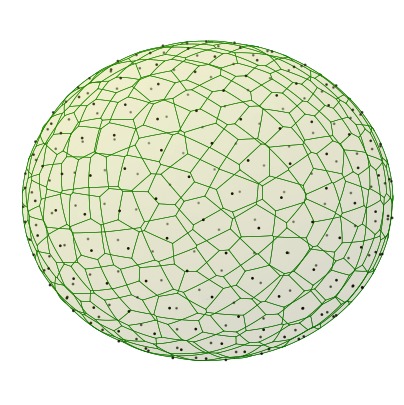

In [1]:
from gal3d.field.spherical_field.spherical_vector import SphVector
from gal3d.log import set_logging_level
set_logging_level(80)

import matplotlib.pyplot as plt
from scipy.spatial import geometric_slerp
import numpy as np


rays = SphVector(256,method='fibonacci')

t_vals = np.linspace(0, 1, 10)

fig = plt.figure(dpi=100, figsize=(5, 5))
ax = fig.add_subplot(111, projection='3d')

u = np.linspace(0, 2 * np.pi, 100)
v = np.linspace(0, np.pi, 100)
x = np.outer(np.cos(u), np.sin(v))
y = np.outer(np.sin(u), np.sin(v))
z = np.outer(np.ones(np.size(u)), np.cos(v))
ax.plot_surface(x, y, z, color='y', alpha=0.1)

# plot generator points
ax.scatter(rays.pos[:, 0], rays.pos[:, 1], rays.pos[:, 2], c='k', s=1)

for region in rays.voronoi.regions:
    n = len(region)
    for i in range(n):
        start = rays.voronoi.vertices[region][i]
        end = rays.voronoi.vertices[region][(i + 1) % n]
        result = geometric_slerp(start, end, t_vals)
        ax.plot(result[..., 0], result[..., 1], result[..., 2], c='g', linewidth=0.4)

ax.azim = 10
ax.elev = 40
ax.axis("off")

siz = 0.67
ax.set_xlim(-siz, siz)
ax.set_ylim(-siz, siz)
ax.set_zlim(-siz, siz)
plt.show()

Voronoi Cells and the Area Distribution of Sample Points
--------------------------------------------------------

By constructing the Voronoi tessellation on the sphere, shown as the green grid in the figure above, we can compute the area associated with each sample point. For an ideal uniform sampling, the Voronoi area of each point should be close to $\frac{4\pi}{N}$. The figure below shows the distribution of Voronoi-cell areas for the case $N=256$:

- **Area distribution**: most regions have areas close to the ideal value.
- **Error range**: for most sample points, the error is within 2%.

Using the spherical Voronoi tessellation, shown as the green grid in the figure above, we can compute the area associated with each sample point. For ideal uniform sampling, the Voronoi area of every sample point should be equal to $\frac{4\pi}{N}$. The figure below shows the distribution of Voronoi-cell areas for all sample points. Most regions are close to the ideal value, and for most sample points the error is within 2%.

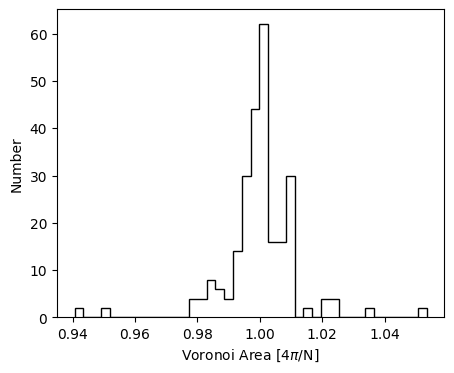

In [2]:
plt.figure(dpi=100,figsize=(5,4))
plt.hist(rays.area/(4*np.pi/256), bins=40,histtype='step',color='k')
plt.xlabel("Voronoi Area [4$\pi$/N]")
plt.ylabel("Number")
plt.show()

Definition and Analysis of Sampling Uniformity
---------------------------------------------

We define the uniformity of the sampling as

$$
\text{Uniformity} = 1 - \frac{\sum_{i=1}^{N}\left|A_i - \frac{4\pi}{N}\right|}{4\pi},
$$

where $A_i$ is the Voronoi-cell area of the $i$-th sample point. If $\text{Uniformity} \approx 1$, the sampling is considered highly uniform.

The figure below shows how the uniformity changes with the number of sample points $N$:

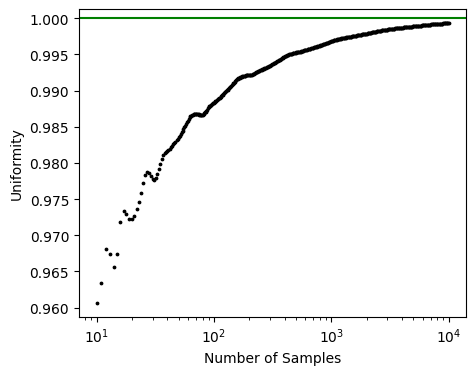

In [3]:
n_values = np.unique(np.geomspace(10, 1e4, 500).astype(int))
uni = [SphVector(n_sample=i).uniformity for i in n_values]
plt.figure(dpi=100,figsize=(5,4))
plt.scatter(n_values, uni, c='k', marker='o',s=3)
plt.xscale('log')
plt.yscale('linear')
plt.xlabel('Number of Samples')
plt.ylabel('Uniformity')
plt.axhline(1,c='g')
plt.show()